# Actividad 13 – Comparar umbrales

**Objetivo**: entender diferencias entre métodos de umbralización.

En esta actividad vamos a:
1. Cargar una imagen
2. Aplicar THRESH_BINARY
3. Aplicar THRESH_BINARY_INV
4. Aplicar método de Otsu
5. Aplicar umbralización adaptativa
6. Mostrar las cuatro versiones
7. Analizar cuál funciona mejor

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

Cambia la ruta por la ubicación de tu imagen.

✓ Imagen cargada correctamente


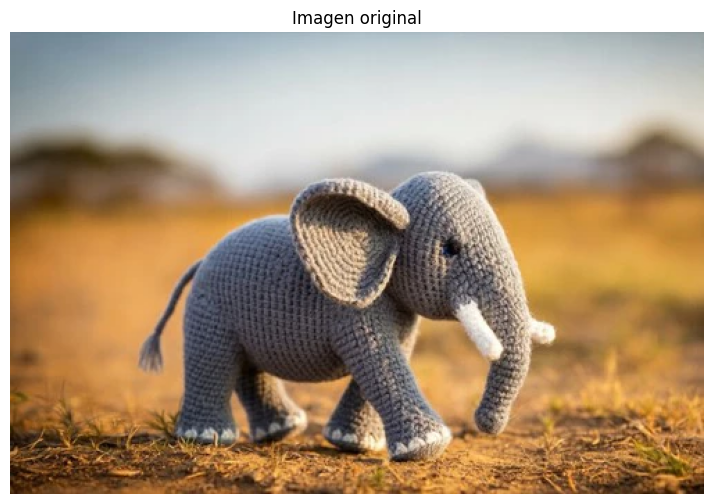

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Mostrar la imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen original')
    plt.show()

## 3. Convertir a escala de grises

Todos los métodos de umbralización requieren imagen en escala de grises.

✓ Imagen convertida a escala de grises
  Dimensiones: (333, 500)
  Tipo de dato: uint8
  Valores mín/máx: 1 / 254


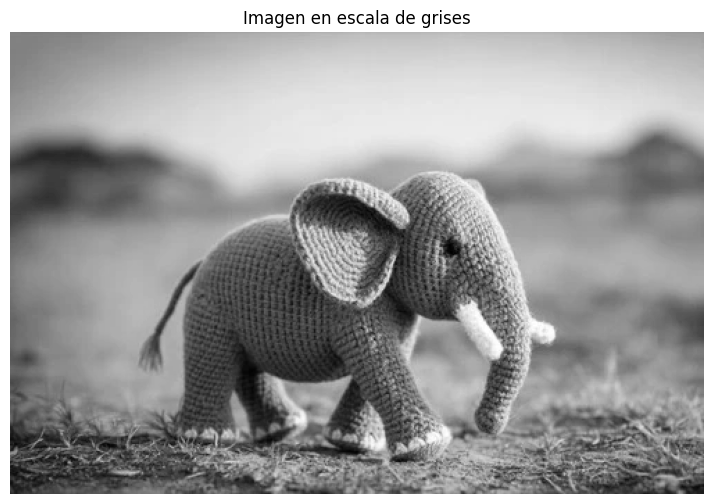

In [3]:
# Convertir a escala de grises
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

print("✓ Imagen convertida a escala de grises")
print(f"  Dimensiones: {imagen_gris.shape}")
print(f"  Tipo de dato: {imagen_gris.dtype}")
print(f"  Valores mín/máx: {imagen_gris.min()} / {imagen_gris.max()}")

plt.figure(figsize=(10, 6))
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen en escala de grises')
plt.axis('off')
plt.show()

## 4. Aplicar THRESH_BINARY

Convierte píxeles por encima del umbral a blanco (255) y por debajo a negro (0).

✓ THRESH_BINARY aplicado
  Umbral usado: 127
  Valor máximo: 255
  Píxeles blancos: 108434
  Píxeles negros: 58066


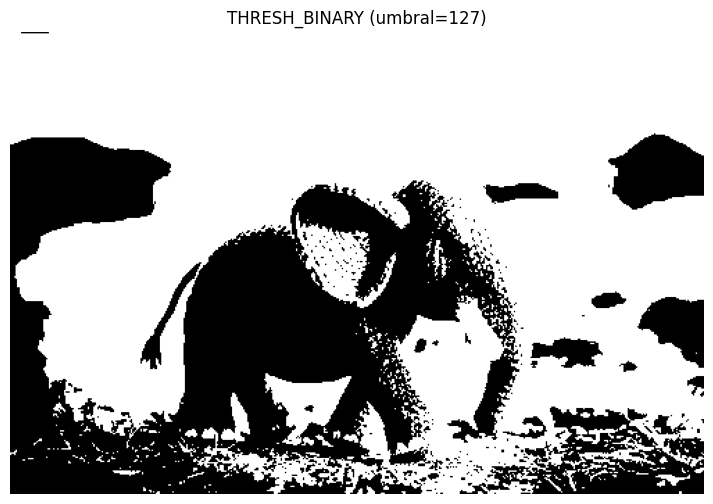

In [4]:
# Aplicar umbralización binaria
# Píxeles > umbral = 255 (blanco)
# Píxeles <= umbral = 0 (negro)
umbral_valor = 127
valor_maximo = 255

retval1, thresh_binary = cv2.threshold(imagen_gris, umbral_valor, valor_maximo, cv2.THRESH_BINARY)

print(f"✓ THRESH_BINARY aplicado")
print(f"  Umbral usado: {umbral_valor}")
print(f"  Valor máximo: {valor_maximo}")
print(f"  Píxeles blancos: {np.sum(thresh_binary == 255)}")
print(f"  Píxeles negros: {np.sum(thresh_binary == 0)}")

plt.figure(figsize=(10, 6))
plt.imshow(thresh_binary, cmap='gray')
plt.title(f'THRESH_BINARY (umbral={umbral_valor})')
plt.axis('off')
plt.show()

## 5. Aplicar THRESH_BINARY_INV

Invierte el resultado: píxeles por encima del umbral a negro y por debajo a blanco.

✓ THRESH_BINARY_INV aplicado
  Umbral usado: 127
  Píxeles blancos: 58066
  Píxeles negros: 108434


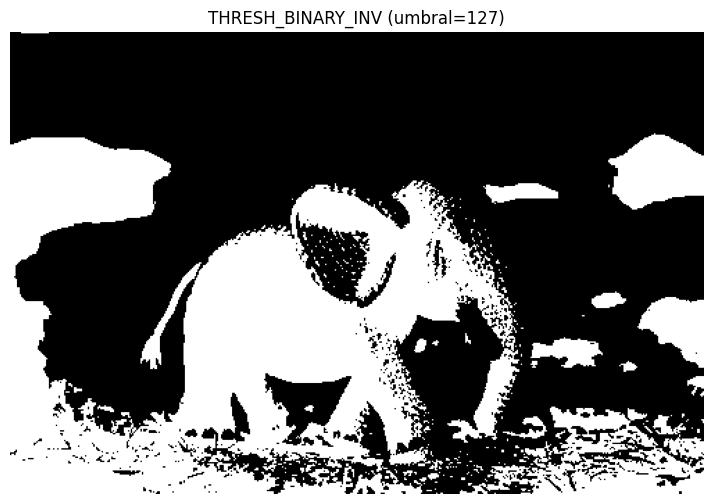

In [5]:
# Aplicar umbralización binaria invertida
# Píxeles > umbral = 0 (negro)
# Píxeles <= umbral = 255 (blanco)
retval2, thresh_binary_inv = cv2.threshold(imagen_gris, umbral_valor, valor_maximo, cv2.THRESH_BINARY_INV)

print(f"✓ THRESH_BINARY_INV aplicado")
print(f"  Umbral usado: {umbral_valor}")
print(f"  Píxeles blancos: {np.sum(thresh_binary_inv == 255)}")
print(f"  Píxeles negros: {np.sum(thresh_binary_inv == 0)}")

plt.figure(figsize=(10, 6))
plt.imshow(thresh_binary_inv, cmap='gray')
plt.title(f'THRESH_BINARY_INV (umbral={umbral_valor})')
plt.axis('off')
plt.show()

## 6. Aplicar método de Otsu

Otsu calcula automáticamente el umbral óptimo basándose en el histograma de la imagen.

✓ Método de Otsu aplicado
  Umbral calculado automáticamente: 134.00
  (Otsu determina el umbral óptimo del histograma)
  Píxeles blancos: 101443
  Píxeles negros: 65057


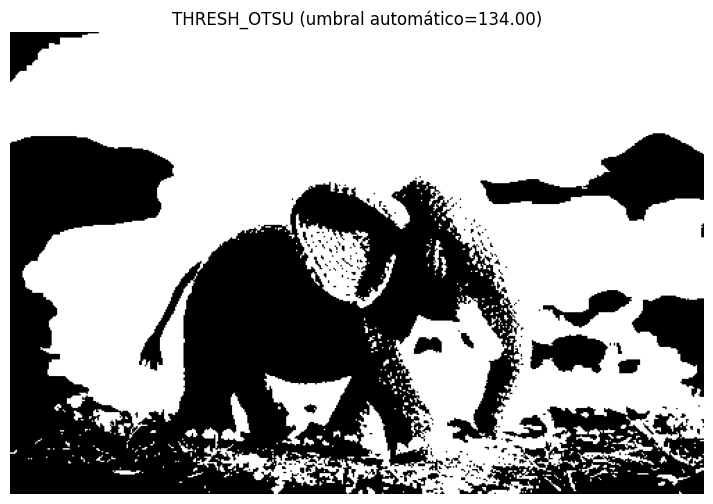

In [6]:
# Aplicar método de Otsu
# El umbral se calcula automáticamente
# El valor de umbral manual se ignora cuando se usa THRESH_OTSU
retval_otsu, thresh_otsu = cv2.threshold(imagen_gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"✓ Método de Otsu aplicado")
print(f"  Umbral calculado automáticamente: {retval_otsu:.2f}")
print(f"  (Otsu determina el umbral óptimo del histograma)")
print(f"  Píxeles blancos: {np.sum(thresh_otsu == 255)}")
print(f"  Píxeles negros: {np.sum(thresh_otsu == 0)}")

plt.figure(figsize=(10, 6))
plt.imshow(thresh_otsu, cmap='gray')
plt.title(f'THRESH_OTSU (umbral automático={retval_otsu:.2f})')
plt.axis('off')
plt.show()

## 7. Aplicar umbralización adaptativa

La umbralización adaptativa calcula diferentes umbrales para diferentes regiones de la imagen, útil para iluminación no uniforme.

✓ Umbralización adaptativa aplicada
  Método: ADAPTIVE_THRESH_GAUSSIAN_C
  Block size: 11
  Constante C: 2
  (El umbral se calcula localmente para cada región)


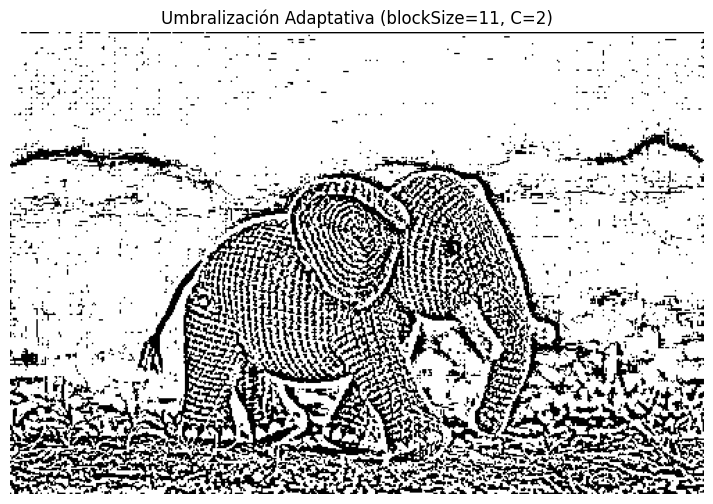

In [7]:
# Aplicar umbralización adaptativa
# Método: ADAPTIVE_THRESH_GAUSSIAN_C (promedio ponderado gaussiano)
# Parámetros:
# - blockSize: tamaño del vecindario (debe ser impar)
# - C: constante que se resta del promedio
blockSize = 11
C = 2

thresh_adaptive = cv2.adaptiveThreshold(imagen_gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                        cv2.THRESH_BINARY, blockSize, C)

print(f"✓ Umbralización adaptativa aplicada")
print(f"  Método: ADAPTIVE_THRESH_GAUSSIAN_C")
print(f"  Block size: {blockSize}")
print(f"  Constante C: {C}")
print(f"  (El umbral se calcula localmente para cada región)")

plt.figure(figsize=(10, 6))
plt.imshow(thresh_adaptive, cmap='gray')
plt.title(f'Umbralización Adaptativa (blockSize={blockSize}, C={C})')
plt.axis('off')
plt.show()

## 8. Mostrar todas las versiones juntas

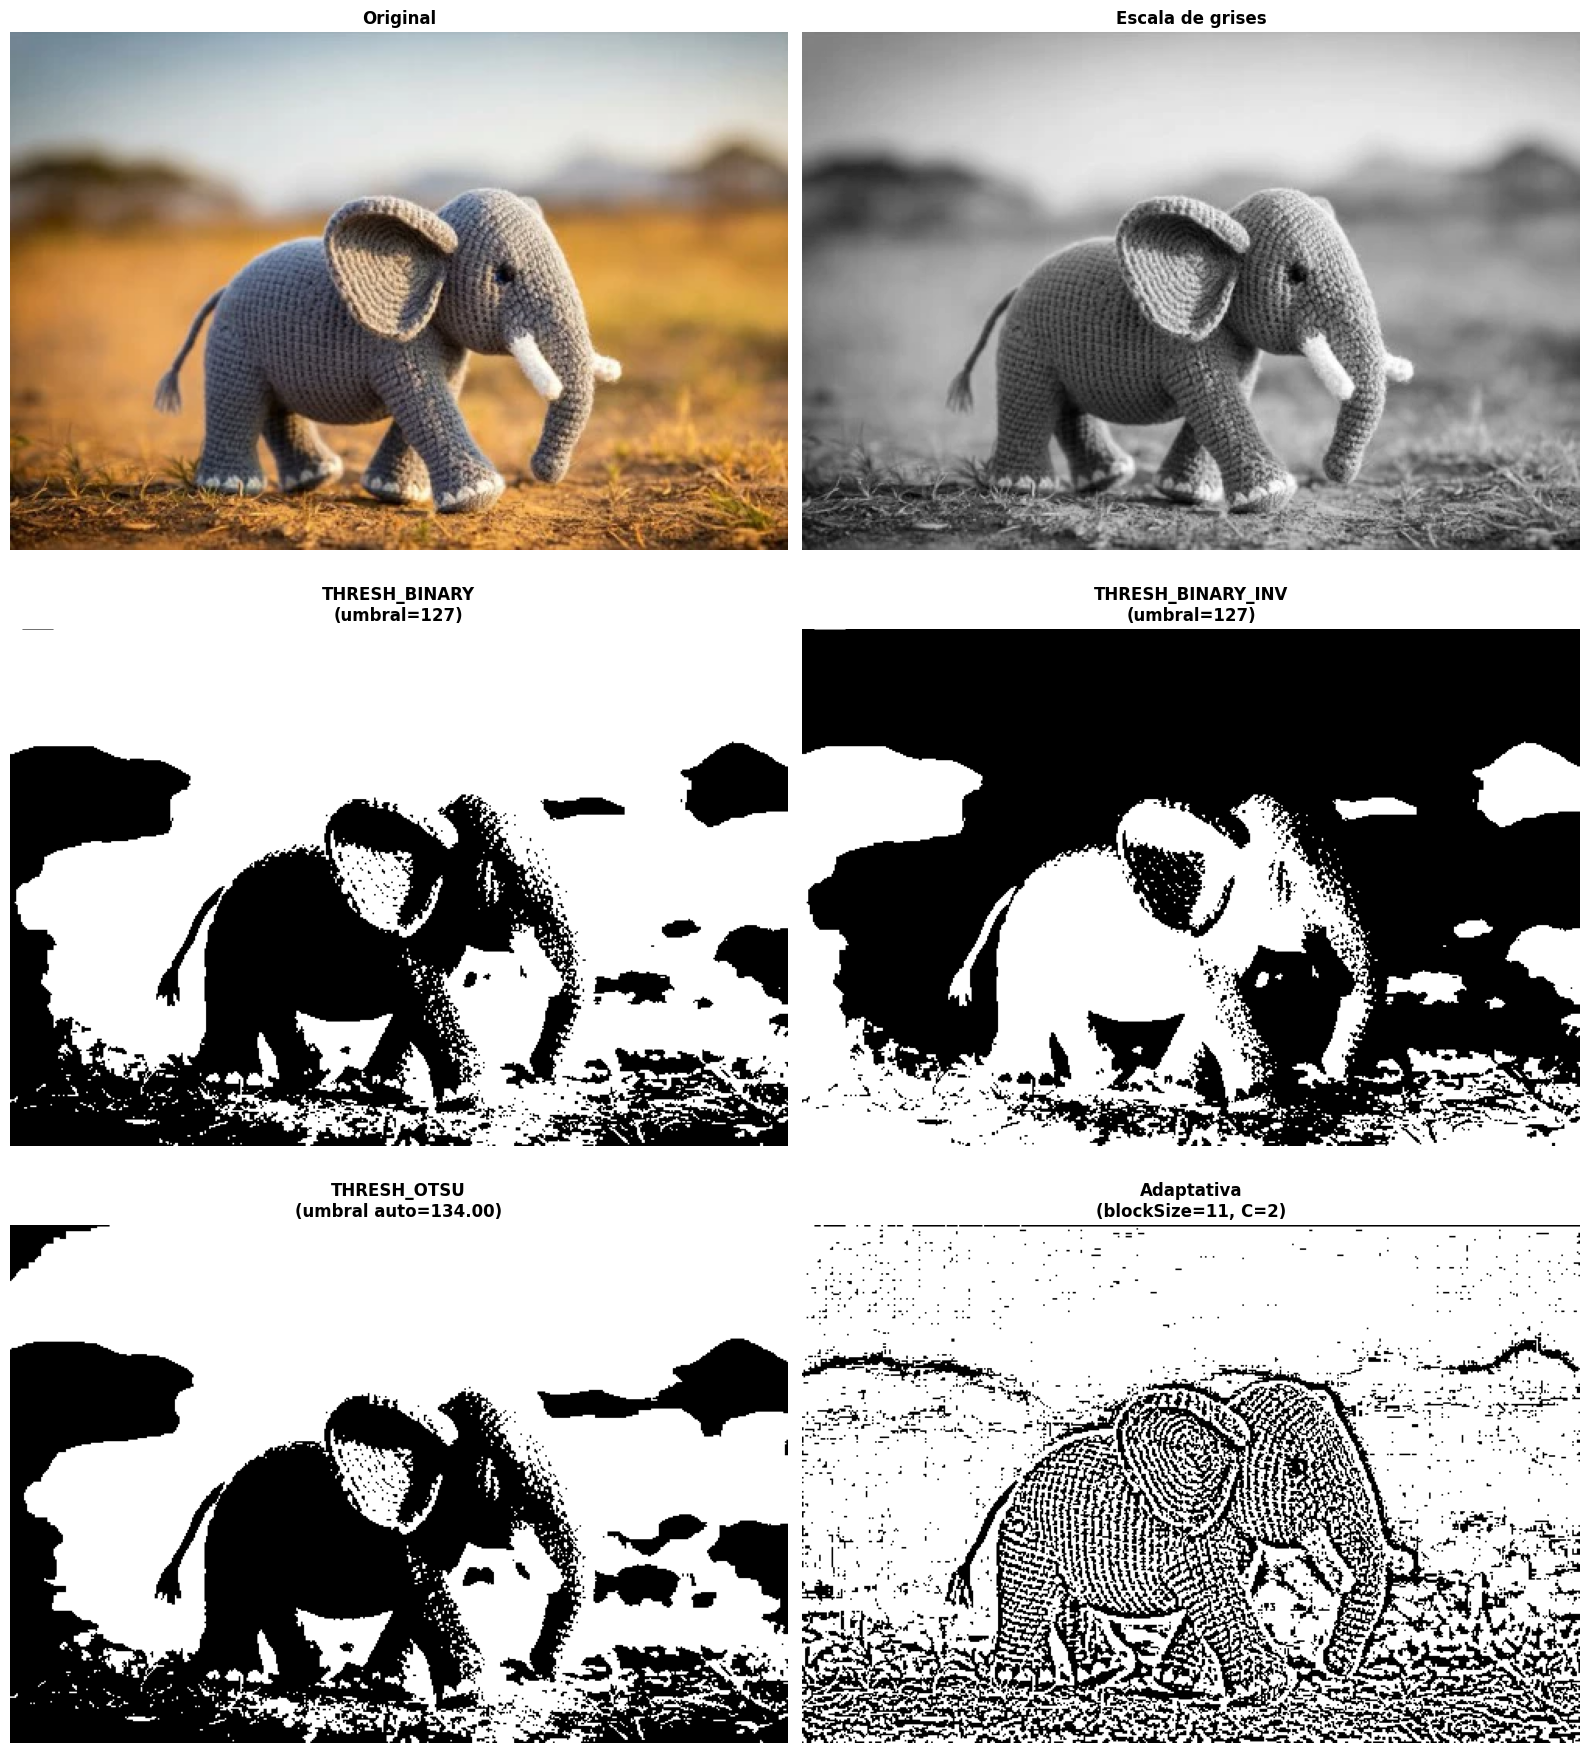

In [8]:
# Mostrar todas las versiones en una cuadrícula 3x2
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Imagen original
axes[0, 0].imshow(imagen_rgb)
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Escala de grises
axes[0, 1].imshow(imagen_gris, cmap='gray')
axes[0, 1].set_title('Escala de grises', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# THRESH_BINARY
axes[1, 0].imshow(thresh_binary, cmap='gray')
axes[1, 0].set_title(f'THRESH_BINARY\n(umbral={umbral_valor})', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# THRESH_BINARY_INV
axes[1, 1].imshow(thresh_binary_inv, cmap='gray')
axes[1, 1].set_title(f'THRESH_BINARY_INV\n(umbral={umbral_valor})', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

# Método de Otsu
axes[2, 0].imshow(thresh_otsu, cmap='gray')
axes[2, 0].set_title(f'THRESH_OTSU\n(umbral auto={retval_otsu:.2f})', fontsize=12, fontweight='bold')
axes[2, 0].axis('off')

# Umbralización adaptativa
axes[2, 1].imshow(thresh_adaptive, cmap='gray')
axes[2, 1].set_title(f'Adaptativa\n(blockSize={blockSize}, C={C})', fontsize=12, fontweight='bold')
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()